In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve, auc, make_scorer
import seaborn as sns

In [2]:
df = pd.read_csv("INDENG ECOM.csv")
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [3]:
nan_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

for col in nan_cols:
    df[col] = df[col].fillna(df[col].median())

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.134103,1.654707,15.566785,2.934636,3.688988,3.066785,4.214032,0.284902,15.674600,1.716874,2.961812,4.459325,177.221492
std,1625.385339,0.374240,8.357951,0.915389,8.345961,0.705528,1.023999,1.380194,2.583586,0.451408,3.591058,1.857640,2.879248,3.570626,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64

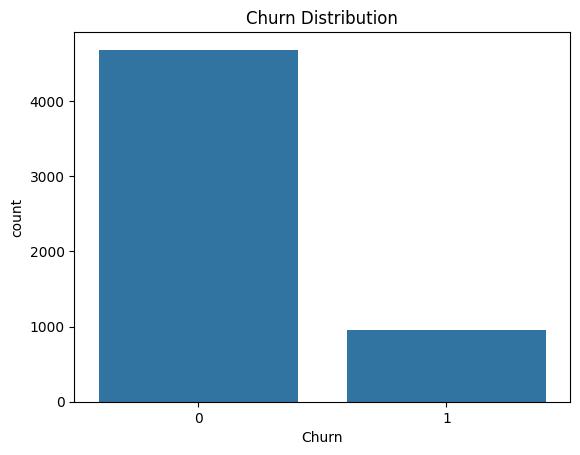

In [5]:
sns.countplot(x=df["Churn"])
plt.title("Churn Distribution")

churn_counts = df["Churn"].value_counts(normalize=True)
churn_counts

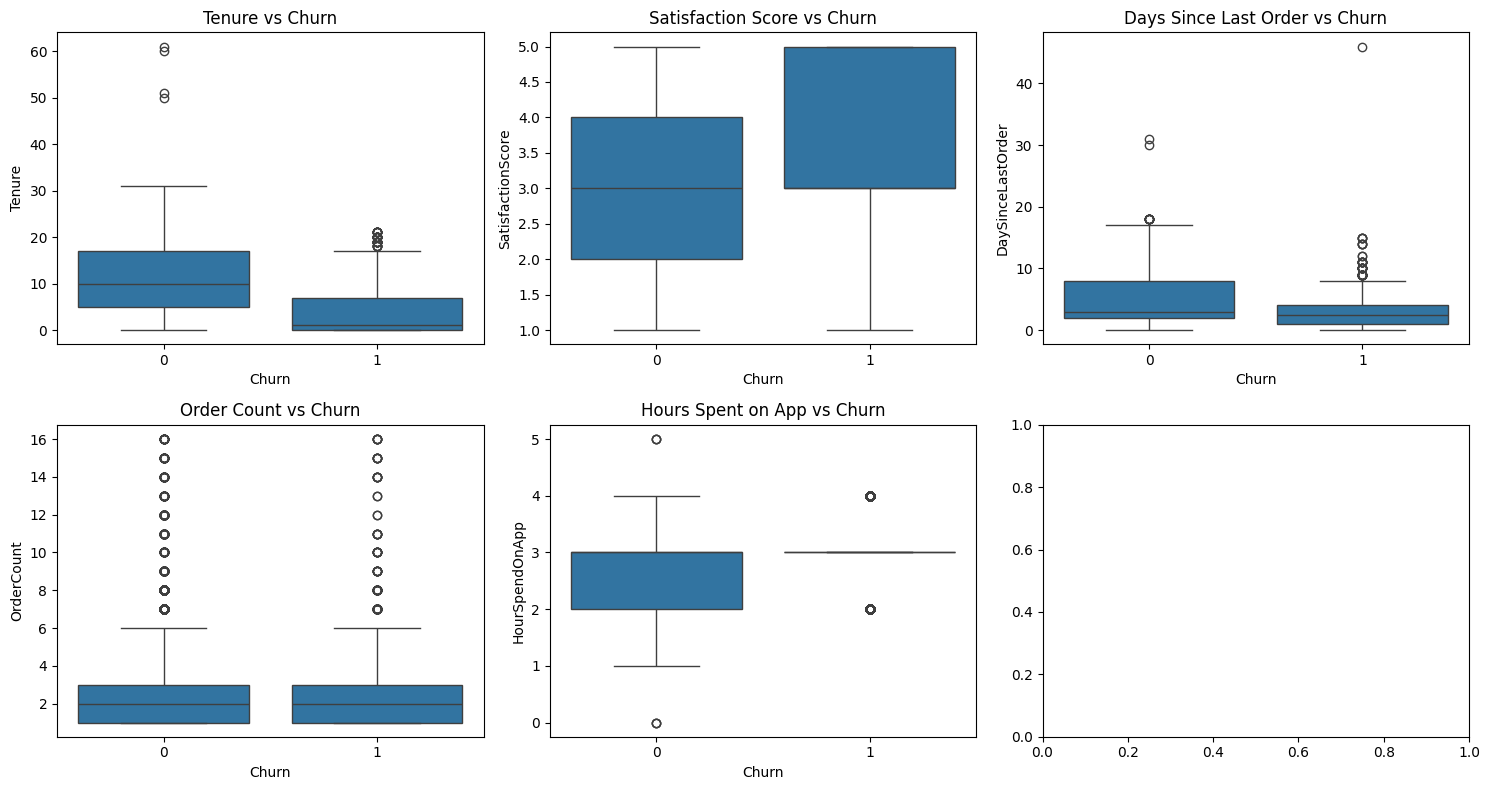

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(x="Churn", y="Tenure", data=df, ax=axes[0,0])
axes[0,0].set_title("Tenure vs Churn")

sns.boxplot(x="Churn", y="SatisfactionScore", data=df, ax=axes[0,1])
axes[0,1].set_title("Satisfaction Score vs Churn")

sns.boxplot(x="Churn", y="DaySinceLastOrder", data=df, ax=axes[0,2])
axes[0,2].set_title("Days Since Last Order vs Churn")

sns.boxplot(x="Churn", y="OrderCount", data=df, ax=axes[1,0])
axes[1,0].set_title("Order Count vs Churn")

sns.boxplot(x="Churn", y="HourSpendOnApp", data=df, ax=axes[1,1])
axes[1,1].set_title("Hours Spent on App vs Churn")

fig.tight_layout()
plt.show()

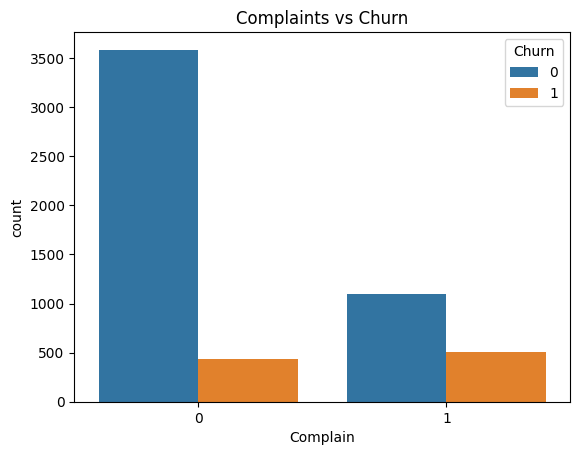

In [7]:
sns.countplot(x="Complain", hue="Churn", data=df)
plt.title("Complaints vs Churn")
plt.show()

In [8]:
df = df.drop("CustomerID", axis=1)
onehot_cols = ["PreferredLoginDevice",
            "PreferredPaymentMode",
            "Gender",
            "PreferedOrderCat",
            "MaritalStatus"]

df_encoded = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
df_encoded.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,False,True,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,True,False,False,True,False,False,False,True


In [9]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:


def compute_performance_metrics(y_test, y_pred):
    TP = np.sum((y_pred == 1) & (y_test == 1))
    FP = np.sum((y_pred == 1) & (y_test == 0))
    TN = np.sum((y_pred == 0) & (y_test == 0))
    FN = np.sum((y_pred == 0) & (y_test == 1))

    acc = (TP + TN) / (TP + TN + FP + FN)
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN)
    pre = TP / (TP + FP) if (TP + FP) > 0 else 0

    return acc, tpr, fpr, pre

def compute_auc(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return roc_auc


def perform_bootstrap(X_test, y_test, models, n_samples=500, random_state=88):

    y_test = np.array(y_test)
    rng = np.random.default_rng(random_state)
    results = {}
    n = X_test.shape[0]

    for model_name, model in models.items():

        y_pred = model.predict(X_test)

        acc_bootstraps = []
        tpr_bootstraps = []
        fpr_bootstraps = []
        pre_bootstraps = []

        for i in range(n_samples):
            idx = rng.integers(0, n, size=n)
            y_pred_bootstrap = y_pred[idx]
            y_test_boot = y_test[idx]
            acc_boot, tpr_boot, fpr_boot, pre_boot = \
                compute_performance_metrics(y_test_boot, y_pred_bootstrap)

            acc_bootstraps.append(acc_boot)
            tpr_bootstraps.append(tpr_boot)
            fpr_bootstraps.append(fpr_boot)
            pre_bootstraps.append(pre_boot)

        results[model_name] = {
            "accuracy": np.array(acc_bootstraps),
            "TPR": np.array(tpr_bootstraps),
            "FPR": np.array(fpr_bootstraps),
            "precision": np.array(pre_bootstraps),
        }

    return results


In [11]:
# Baseline zero model
y_pred_baseline = np.zeros(len(y_test))
y_prob_baseline = np.zeros(len(y_test))
[acc_baseline, tpr_baseline, fpr_baseline, pre_baseline] = compute_performance_metrics(y_test, y_pred_baseline)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
auc_baseline = compute_auc(y_test, y_prob_baseline)
display(cm_baseline)

array([[936,   0],
       [190,   0]])

In [12]:
# Logistic model trained on all featured normalized
log_model = LogisticRegression(max_iter=300).fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
[acc_log, tpr_log, fpr_log, pre_log] = compute_performance_metrics(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
auc_log = compute_auc(y_test, y_prob_log)
display(cm_log)
print(auc_log)

array([[902,  34],
       [ 91,  99]])

0.8872413405308142


In [13]:
# LDA trained on all features normalized
lda_model = LinearDiscriminantAnalysis().fit(X_train_scaled, y_train)
y_pred_lda = lda_model.predict(X_test_scaled)
y_prob_lda = lda_model.predict_proba(X_test_scaled)[:, 1]
[acc_lda, tpr_lda, fpr_lda, pre_lda] = compute_performance_metrics(y_test, y_pred_lda)
cm_lda = confusion_matrix(y_test, y_pred_lda)
auc_lda = compute_auc(y_test, y_prob_lda)
display(cm_lda)

array([[905,  31],
       [ 90, 100]])

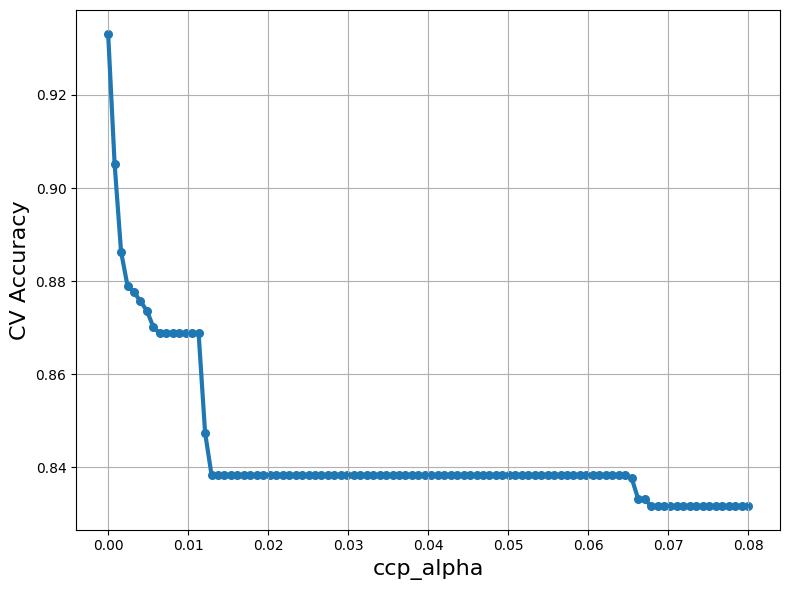

array([[921,  15],
       [ 15, 175]])

In [14]:
# CV ccp alpha, leave everything else as default. Tree was trained on unormalized features

tree_model = DecisionTreeClassifier(random_state=88)

grid_values_tree = {'ccp_alpha': np.linspace(0, 0.08, 100)}
cv_tree = StratifiedKFold(n_splits=5, random_state=88, shuffle=True)

tree_model_cv = GridSearchCV(tree_model, param_grid=grid_values_tree, \
                                      scoring='accuracy', cv=cv_tree, verbose=0)
tree_model_cv.fit(X_train, y_train)

ccp_alpha = tree_model_cv.cv_results_['param_ccp_alpha'].data
precision_scores = tree_model_cv.cv_results_['mean_test_score']

plt.figure(figsize=(8, 6))
plt.xlabel('ccp_alpha', fontsize=16)
plt.ylabel('CV Accuracy', fontsize=16)
plt.scatter(ccp_alpha, precision_scores, s=30)
plt.plot(ccp_alpha, precision_scores, linewidth=3)
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

tree_model = tree_model_cv.best_estimator_

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]
[acc_tree, tpr_tree, fpr_tree, pre_tree] = compute_performance_metrics(y_test, y_pred_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)
auc_tree = compute_auc(y_test, y_prob_tree)

display(cm_tree)

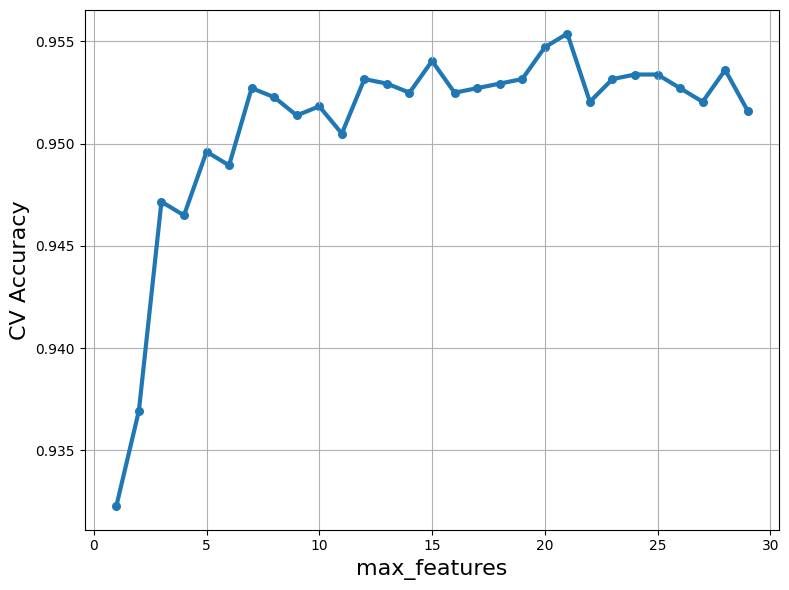

array([[932,   4],
       [ 16, 174]])

In [15]:
# CV max features, leave everything else as default. RF was trained on unnormalized features
rf_model = RandomForestClassifier(random_state=88)

grid_values_rf = {'max_features': np.arange(1, X_train.shape[1]+1)}
cv_rf = KFold(n_splits=5, random_state=88, shuffle=True)

rf_model_cv = GridSearchCV(rf_model, param_grid=grid_values_rf, \
                                      scoring='accuracy', cv=cv_rf, verbose=0)
rf_model_cv.fit(X_train, y_train)

max_features_classification = rf_model_cv.cv_results_['param_max_features'].data
precision_scores = rf_model_cv.cv_results_['mean_test_score']

plt.figure(figsize=(8, 6))
plt.xlabel('max_features', fontsize=16)
plt.ylabel('CV Accuracy', fontsize=16)
plt.scatter(max_features_classification, precision_scores, s=30)
plt.plot(max_features_classification, precision_scores, linewidth=3)
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

rf_model = rf_model_cv.best_estimator_

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
[acc_rf, tpr_rf, fpr_rf, pre_rf] = compute_performance_metrics(y_test, y_pred_rf)
cm_rf= confusion_matrix(y_test, y_pred_rf)
auc_rf = compute_auc(y_test, y_prob_rf)

display(cm_rf)

In [16]:
comparison_data = {'Baseline':[acc_baseline, tpr_baseline, fpr_baseline, pre_baseline, auc_baseline],
                   'Logistic Regression':[acc_log, tpr_log, fpr_log, pre_log, auc_log],
                   'Decision Tree Classifier':[acc_tree, tpr_tree, fpr_tree, pre_tree, auc_tree],
                   'Random Forest with CV':[acc_rf, tpr_rf, fpr_rf, pre_rf, auc_rf],
                  'Linear Discriminant Analysis':[acc_lda, tpr_lda, fpr_lda, pre_lda, auc_lda]}

comparison_table = pd.DataFrame(data=comparison_data, index=['Accuracy', 'TPR', 'FPR','PRE', 'AUC']).transpose()
comparison_table.style.set_properties(**{'font-size': '12pt',}).set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}])
comparison_table

,Accuracy,TPR,FPR,PRE,AUC
Baseline,0.831261,0.000000,0.000000,0.000000,0.500000
Logistic Regression,0.888988,0.521053,0.036325,0.744361,0.887241
Decision Tree Classifier,0.973357,0.921053,0.016026,0.921053,0.952513
Random Forest with CV,0.982238,0.915789,0.004274,0.977528,0.997964
Linear Discriminant Analysis,0.892540,0.526316,0.033120,0.763359,0.884374


In [17]:
def bootstrap_summary(metrics):
    rows = []
    for metric, arr in metrics.items():
        mean = arr.mean()
        std = arr.std(ddof=1)
        ci_low, ci_high = np.percentile(arr, [2.5, 97.5])
    
        rows.append({"metric": metric, "mean": mean, "std": std, "ci_low": ci_low,
                     "ci_high": ci_high})
    
    results_df = pd.DataFrame(rows)
    return results_df

In [18]:
scaled_models = {"Logistic": log_model, "LDA": lda_model}
unscaled_models = {"Decision Tree": tree_model, "Random Forest": rf_model}
results_scaled = perform_bootstrap(X_test_scaled, y_test, scaled_models)
results_unscaled = perform_bootstrap(X_test, y_test, unscaled_models)
results_merged = results_scaled.copy()
results_merged.update(results_unscaled)

In [19]:
log_metrics = results_merged['Logistic']
lda_metrics = results_merged['LDA']
tree_metrics = results_merged['Decision Tree']
rf_metrics = results_merged['Random Forest']

log_metrics_summary = bootstrap_summary(log_metrics)
lda_metrics_summary = bootstrap_summary(lda_metrics)
tree_metrics_summary = bootstrap_summary(tree_metrics)
rf_metrics_summary = bootstrap_summary(rf_metrics)

print("Logistic Model Bootstrap")
display(log_metrics_summary)

print("LDA Model Bootstrap")
display(lda_metrics_summary)

print("Tree Model Bootstrap")
display(tree_metrics_summary)

print("Random Forest Model Bootstrap")
display(rf_metrics_summary)

Logistic Model Bootstrap


,metric,mean,std,ci_low,ci_high
0,accuracy,0.889043,0.009546,0.869449,0.908526
1,TPR,0.520998,0.034545,0.452288,0.590593
2,FPR,0.036491,0.006280,0.025079,0.049606
3,precision,0.743022,0.037426,0.675427,0.818185


LDA Model Bootstrap


,metric,mean,std,ci_low,ci_high
0,accuracy,0.892758,0.009515,0.873002,0.910346
1,TPR,0.526740,0.035894,0.461432,0.601878
2,FPR,0.033130,0.005841,0.022505,0.045560
3,precision,0.762923,0.036990,0.687023,0.831518


Tree Model Bootstrap


,metric,mean,std,ci_low,ci_high
0,accuracy,0.973519,0.005056,0.964010,0.983126
1,TPR,0.921077,0.021142,0.875675,0.961767
2,FPR,0.015861,0.004298,0.008542,0.025330
3,precision,0.921543,0.020691,0.873584,0.957453


Random Forest Model Bootstrap


,metric,mean,std,ci_low,ci_high
0,accuracy,0.982677,0.003882,0.975133,0.989343
1,TPR,0.917323,0.019323,0.876922,0.954213
2,FPR,0.004090,0.002105,0.000494,0.008557
3,precision,0.978437,0.011058,0.954231,0.997811
